# DSB reproduction


今回は3つのモデル　ConvNextV2 Atto, 

In [5]:
# Cell 1: 学習曲線データの読み込み
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")

def natural_ckpt_key(p: Path):
    m = re.search(r"checkpoint-(\d+)", p.name)
    return int(m.group(1)) if m else -1

def load_log_history(net_name: str):
    run_dir = RUN_ROOT / net_name
    ckpt_dirs = sorted(
        [d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")],
        key=natural_ckpt_key,
    )
    latest = ckpt_dirs[-1]
    state = json.load(open(latest / "trainer_state.json"))
    entries = [e for e in state["log_history"] if "loss" in e]
    steps = np.array([e["step"] for e in entries])
    epochs = np.array([e["epoch"] for e in entries])
    losses = np.array([e["loss"] for e in entries])
    grad_norms = np.array([e.get("grad_norm", np.nan) for e in entries])
    lrs = np.array([e.get("learning_rate", np.nan) for e in entries])
    return {"steps": steps, "epochs": epochs, "loss": losses, "grad_norm": grad_norms, "lr": lrs}

logs = {net: load_log_history(net) for net in ["convnext-atto", "regnet-400mf", "swin-atto"]}
for net, d in logs.items():
    print(f"{net}: {len(d['steps'])} log points, final loss={d['loss'][-1]:.4f}")

convnext-atto: 620 log points, final loss=0.0158
regnet-400mf: 620 log points, final loss=0.8252
swin-atto: 620 log points, final loss=0.2746


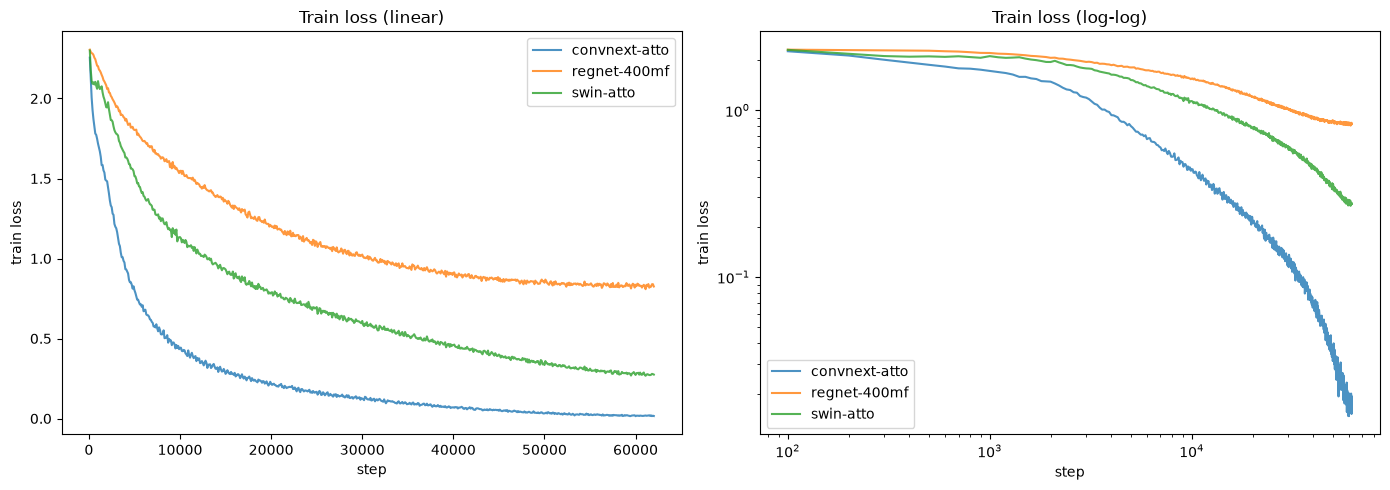

In [6]:
# Cell 2: loss推移の描画(線形スケール + logスケール)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"convnext-atto": "tab:blue", "regnet-400mf": "tab:orange", "swin-atto": "tab:green"}

for net, d in logs.items():
    axes[0].plot(d["steps"], d["loss"], label=net, alpha=0.8, color=colors[net])
    axes[1].plot(d["steps"], d["loss"], label=net, alpha=0.8, color=colors[net])

axes[0].set_xlabel("step")
axes[0].set_ylabel("train loss")
axes[0].set_title("Train loss (linear)")
axes[0].legend()

axes[1].set_xlabel("step")
axes[1].set_ylabel("train loss")
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_title("Train loss (log-log)")
axes[1].legend()

plt.tight_layout()
plt.show()

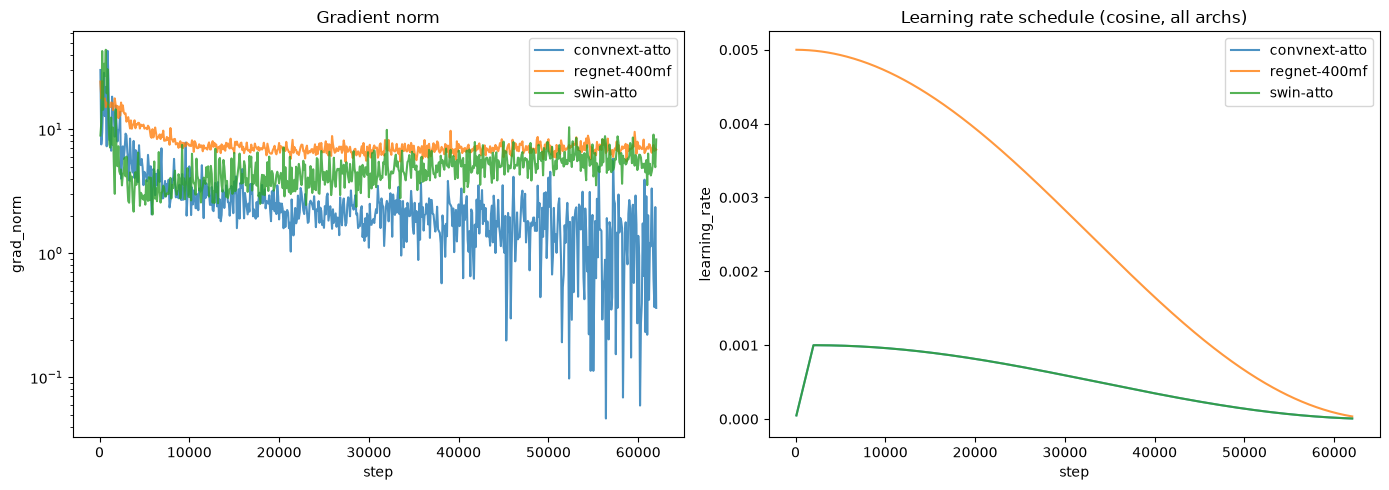

In [7]:
# Cell 3: grad_norm と learning_rate の推移
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for net, d in logs.items():
    axes[0].plot(d["steps"], d["grad_norm"], label=net, alpha=0.8, color=colors[net])
    axes[1].plot(d["steps"], d["lr"], label=net, alpha=0.8, color=colors[net])

axes[0].set_xlabel("step")
axes[0].set_ylabel("grad_norm")
axes[0].set_yscale("log")
axes[0].set_title("Gradient norm")
axes[0].legend()

axes[1].set_xlabel("step")
axes[1].set_ylabel("learning_rate")
axes[1].set_title("Learning rate schedule (cosine, all archs)")
axes[1].legend()

plt.tight_layout()
plt.show()

convnext-atto: 112 points, final test_acc=0.9293
regnet-400mf: 112 points, final test_acc=0.7521
swin-atto: 112 points, final test_acc=0.8927


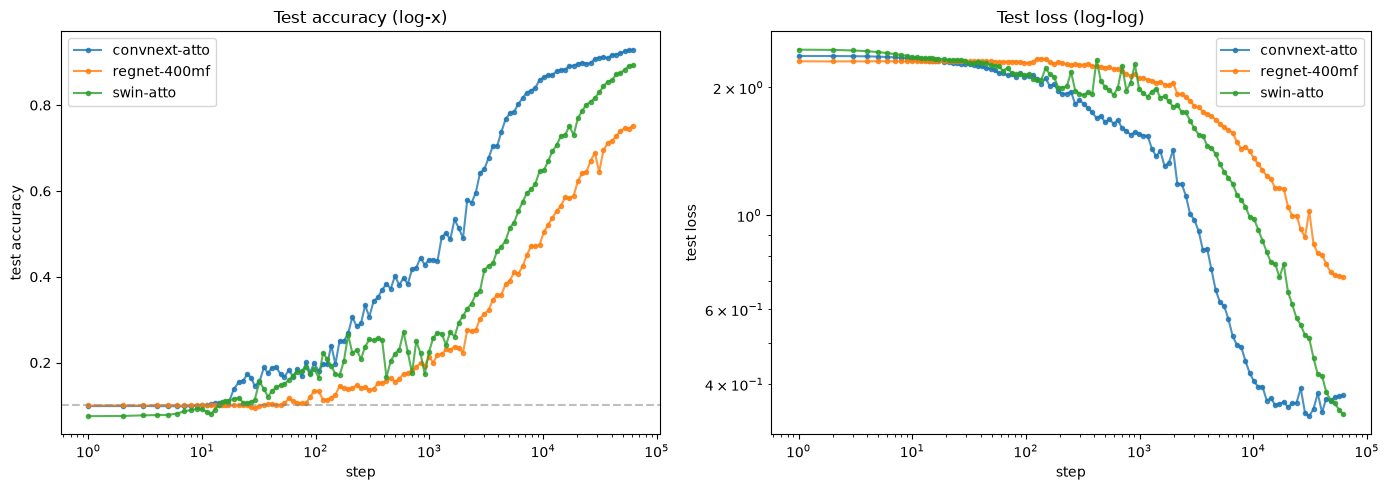

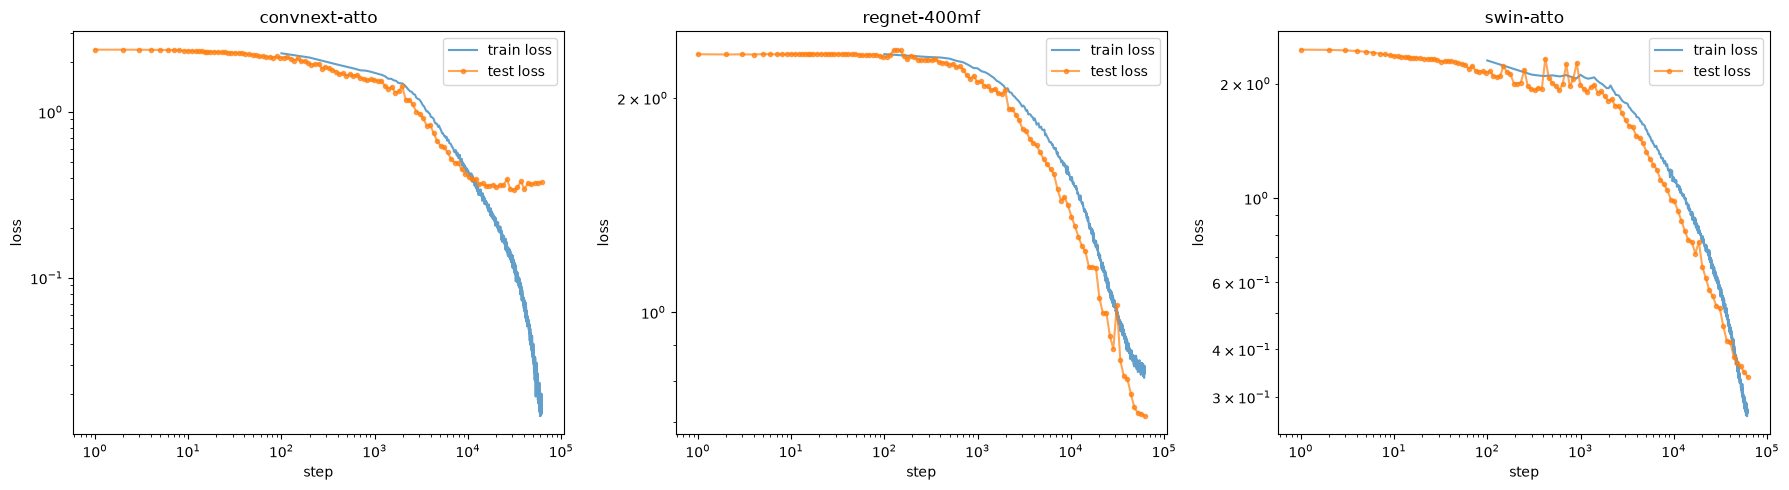

In [8]:
# Cell 4: test accuracy / test loss の読み込み
import pandas as pd

RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")

eval_dfs = {
    net: pd.read_csv(RUN_ROOT / net / "eval_curve.csv").sort_values("step")
    for net in ["convnext-atto", "regnet-400mf", "swin-atto"]
}

for net, df in eval_dfs.items():
    print(f"{net}: {len(df)} points, final test_acc={df['test_acc'].iloc[-1]:.4f}")
    
# Cell 5: test accuracy / test loss の推移(線形 + log-x)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for net, df in eval_dfs.items():
    axes[0].plot(df["step"], df["test_acc"], label=net, alpha=0.8, color=colors[net], marker='.')
    axes[1].plot(df["step"], df["test_loss"], label=net, alpha=0.8, color=colors[net], marker='.')

axes[0].set_xlabel("step")
axes[0].set_ylabel("test accuracy")
axes[0].set_xscale("log")
axes[0].set_title("Test accuracy (log-x)")
axes[0].legend()
axes[0].axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='random baseline')

axes[1].set_xlabel("step")
axes[1].set_ylabel("test loss")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Test loss (log-log)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cell 6: train loss vs test loss(汎化ギャップ)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, net in enumerate(["convnext-atto", "regnet-400mf", "swin-atto"]):
    train_d = logs[net]
    test_d = eval_dfs[net]
    axes[i].plot(train_d["steps"], train_d["loss"], label="train loss", alpha=0.7)
    axes[i].plot(test_d["step"], test_d["test_loss"], label="test loss", alpha=0.7, marker='.')
    axes[i].set_xlabel("step")
    axes[i].set_ylabel("loss")
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")
    axes[i].set_title(net)
    axes[i].legend()

plt.tight_layout()
plt.show()

DSBの結果

In [9]:
# Cell 7: moment_data評価結果の読み込み
RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")
NETS = ["convnext-atto", "regnet-400mf", "swin-atto"]

moment_dfs = {}
for net in NETS:
    df_graft = pd.read_csv(RUN_ROOT / net / "moment_eval_graft.csv")
    df_del = pd.read_csv(RUN_ROOT / net / "moment_eval_del.csv")
    moment_dfs[net] = pd.concat([df_graft, df_del], ignore_index=True).sort_values(["condition", "step"])

for net, df in moment_dfs.items():
    print(f"{net}: {df['condition'].nunique()} conditions, {len(df)} rows")

convnext-atto: 7 conditions, 784 rows
regnet-400mf: 7 conditions, 784 rows
swin-atto: 7 conditions, 784 rows


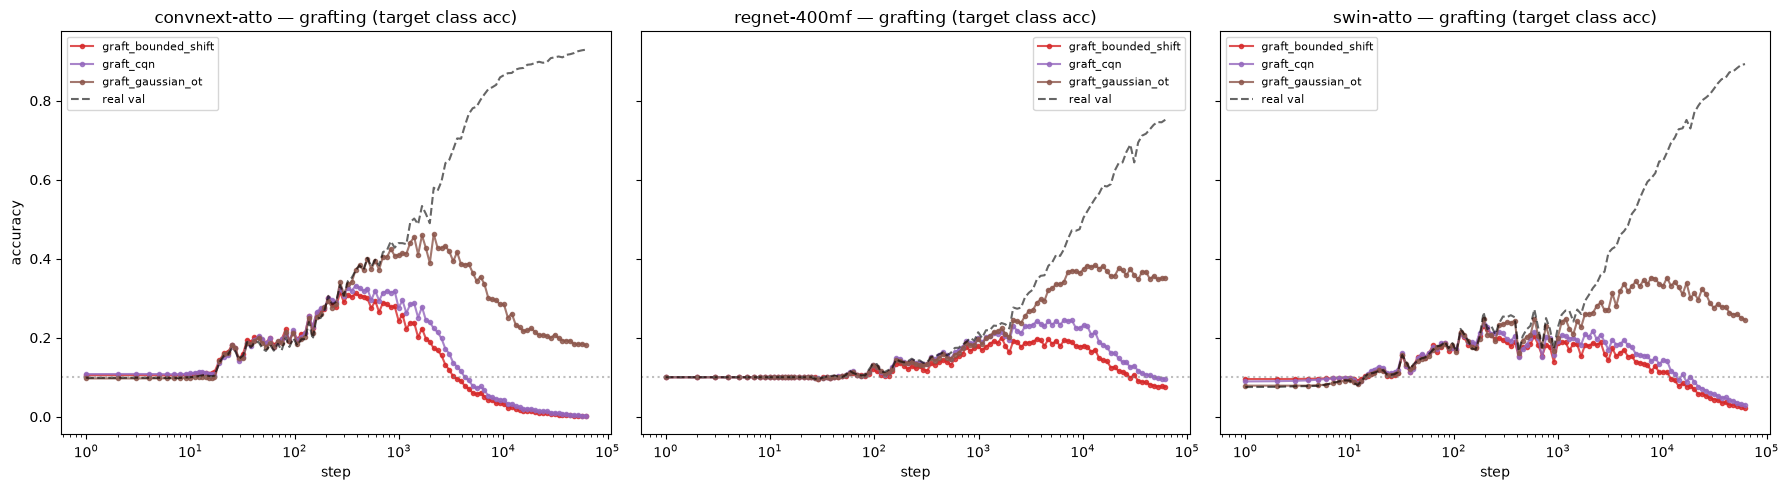

In [10]:
# Cell 8: grafting accuracy推移(論文Fig.3相当) — モデルごとにパネルを分ける
graft_conditions = ["graft_bounded_shift", "graft_cqn", "graft_gaussian_ot"]
graft_colors = {"graft_bounded_shift": "tab:red", "graft_cqn": "tab:purple", "graft_gaussian_ot": "tab:brown"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, net in enumerate(NETS):
    df = moment_dfs[net]
    for cond in graft_conditions:
        sub = df[df["condition"] == cond].sort_values("step")
        axes[i].plot(sub["step"], sub["acc"], label=cond, color=graft_colors[cond], marker='.', alpha=0.8)
    # 通常のtest accuracyも重ねる(参照用)
    axes[i].plot(eval_dfs[net]["step"], eval_dfs[net]["test_acc"], label="real val", color="black", linestyle="--", alpha=0.6)
    axes[i].axhline(0.1, color='gray', linestyle=':', alpha=0.5)
    axes[i].set_xscale("log")
    axes[i].set_xlabel("step")
    axes[i].set_title(f"{net} — grafting (target class acc)")
    axes[i].legend(fontsize=8)

axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.show()

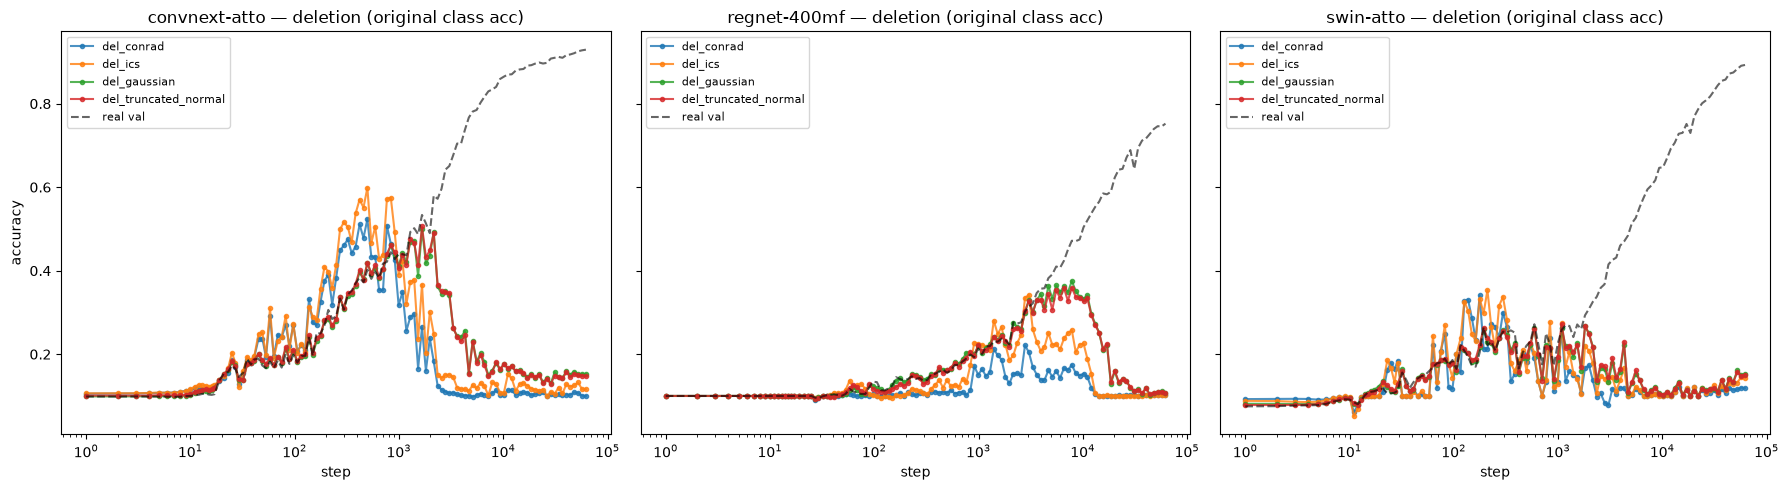

In [11]:
# Cell 9: deletion accuracy推移(論文Fig.5相当)
del_conditions = ["del_conrad", "del_ics", "del_gaussian", "del_truncated_normal"]
del_colors = {"del_conrad": "tab:blue", "del_ics": "tab:orange", "del_gaussian": "tab:green", "del_truncated_normal": "tab:red"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, net in enumerate(NETS):
    df = moment_dfs[net]
    for cond in del_conditions:
        sub = df[df["condition"] == cond].sort_values("step")
        axes[i].plot(sub["step"], sub["acc"], label=cond, color=del_colors[cond], marker='.', alpha=0.8)
    axes[i].plot(eval_dfs[net]["step"], eval_dfs[net]["test_acc"], label="real val", color="black", linestyle="--", alpha=0.6)
    axes[i].set_xscale("log")
    axes[i].set_xlabel("step")
    axes[i].set_title(f"{net} — deletion (original class acc)")
    axes[i].legend(fontsize=8)

axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.show()